In [1]:
import random
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import networkit as nk
import networkx as nx
import numpy as np
from networkit.embedding import Node2Vec
from sklearn.metrics import f1_score, classification_report
import pandas as pd
import time
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
nk.engineering.setNumberOfThreads(1)

## Networkit documentation
https://networkit.github.io/dev-docs/python_api/modules.html

## 1. Analiza sieci citeseer

a) Z wykorzystaniem NetworkX wczytaj sieć z pliku citeseer.adjlist oraz dokonaj transformacji na obiekt networkit.graph.Graph.

In [2]:
data_path = Path('./citeseer/citeseer.adjlist')

G_nx = nx.read_adjlist(data_path, nodetype=int)
print(f"NetworkX – węzły: {G_nx.number_of_nodes()}, krawędzie: {G_nx.number_of_edges()}")

G = nk.nxadapter.nx2nk(G_nx)
print(f"NetworKit – węzły: {G.numberOfNodes()}, krawędzie: {G.numberOfEdges()}")

NetworkX – węzły: 3327, krawędzie: 4552
NetworKit – węzły: 3327, krawędzie: 4552


b) Wykonaj porównanie czasu wykonania implementacji NetworkX oraz networkit algorytmów liczących betweenness centrality oraz liczbę połączonych komponentów.

In [3]:
# --- NetworkX betweenness centrality ---
t0 = time.time()
bc_nx = nx.betweenness_centrality(G_nx, normalized=True)
t_nx_bc = time.time() - t0
print(f"NetworkX betweenness centrality: {t_nx_bc:.4f}s")

# --- NetworKit betweenness centrality ---
t0 = time.time()
bc_nk = nk.centrality.ApproxBetweenness(G, epsilon=0.1)
bc_nk.run()
t_nk_bc = time.time() - t0
print(f"NetworKit ApproxBetweenness: {t_nk_bc:.4f}s")

print(f"Przyspieszenie (NetworKit vs NetworkX): {t_nx_bc/t_nk_bc:.1f}x")

NetworkX betweenness centrality: 6.5497s
NetworKit ApproxBetweenness: 0.0725s
Przyspieszenie (NetworKit vs NetworkX): 90.4x


In [4]:
# --- NetworkX connected components ---
t0 = time.time()
n_comp_nx = nx.number_connected_components(G_nx)
t_nx_cc = time.time() - t0
print(f"NetworkX connected components: {n_comp_nx}, czas: {t_nx_cc:.4f}s")

# --- NetworKit connected components ---
t0 = time.time()
cc_nk = nk.components.ConnectedComponents(G)
cc_nk.run()
n_comp_nk = cc_nk.numberOfComponents()
t_nk_cc = time.time() - t0
print(f"NetworKit connected components: {n_comp_nk}, czas: {t_nk_cc:.4f}s")

print(f"Przyspieszenie: {t_nx_cc/t_nk_cc:.1f}x")

NetworkX connected components: 438, czas: 0.0010s
NetworKit connected components: 438, czas: 0.0002s
Przyspieszenie: 4.3x


c) Przeprowadź analizę sieci wykorzystując bibliotekę networkit wykorzystując funkcję overview oraz moduł netowrkit.centrality.

In [5]:
nk.overview(G)

Network Properties:
nodes, edges			3327, 4552
directed?			False
weighted?			False
isolated nodes			48
self-loops			0
density				0.000823
clustering coefficient		0.141471
min/max/avg degree		0, 99, 2.736399
degree assortativity		0.142213
number of connected components	438
size of largest component	2120 (63.72 %)


In [6]:
# Degree centrality
dc = nk.centrality.DegreeCentrality(G)
dc.run()
dc_scores = dc.scores()

# Top 5 węzłów wg degree centrality
top5 = sorted(enumerate(dc_scores), key=lambda x: -x[1])[:5]
print("Top 5 węzłów wg degree centrality:")
for node, score in top5:
    print(f"- węzeł {node}: {score:.4f}")

Top 5 węzłów wg degree centrality:
- węzeł 60: 99.0000
- węzeł 74: 51.0000
- węzeł 198: 35.0000
- węzeł 109: 34.0000
- węzeł 105: 30.0000


d) Przygotuj wykres rozkładu wybranej miary np. degree.

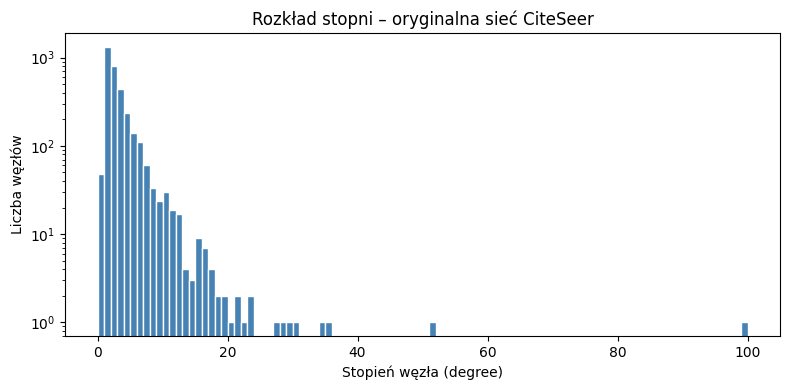

Średni stopień: 2.74, max: 99


In [7]:
degrees = [G.degree(v) for v in G.iterNodes()]

plt.figure(figsize=(8, 4))
plt.hist(degrees, bins=range(max(degrees) + 2), color='steelblue', edgecolor='white')
plt.xlabel('Stopień węzła (degree)')
plt.ylabel('Liczba węzłów')
plt.title('Rozkład stopni – oryginalna sieć CiteSeer')
plt.yscale('log')
plt.tight_layout()
plt.show()
print(f"Średni stopień: {np.mean(degrees):.2f}, max: {max(degrees)}")

## Sparsification

sparsyfikacja jest jednym z typów redukcji grafu, która wybiera istotne węzły i krawędzie, odrzucając pozostałe. W trakcie działania procesu dla danego grafu $G = (A, X)$,  model sparsyfikacji grafu wybiera istniejące węzły lub krawędzie z grafu $G$, tworząc $G' = (A', X')$. Innymi słowy, elementy $A'$ lub $X'$ są podzbiorem elementów w $A$ lub $X$.

## 2. Redukcja z wykorzystaniem algorytmów sparsyfikacji

a) Przeprowadź sparsyfikację sieci wykorzystując algorytm RandomEdgeSparsifier z modułu networkit.sparsification dla edgeRatio = 0.25.

In [8]:
edge_ratio = 0.25

G.indexEdges()

rand_sparsifier = nk.sparsification.RandomEdgeSparsifier()
G_sparse_rand = rand_sparsifier.getSparsifiedGraphOfSize(G, edge_ratio)

print(f"Oryginalny graf – krawędzie: {G.numberOfEdges()}")
print(f"Po RandomEdgeSparsifier (ratio={edge_ratio}) – krawędzie: {G_sparse_rand.numberOfEdges()}")
print(f"Zachowano {100*G_sparse_rand.numberOfEdges()/G.numberOfEdges():.1f}% krawędzi")

Oryginalny graf – krawędzie: 4552
Po RandomEdgeSparsifier (ratio=0.25) – krawędzie: 1131
Zachowano 24.8% krawędzi


b) Powtórz wykres z pierwszej częsci dla zredukowanej sieci oraz analizę z uzyciem overview.

In [9]:
nk.overview(G_sparse_rand)

Network Properties:
nodes, edges			3327, 1131
directed?			False
weighted?			False
isolated nodes			1854
self-loops			0
density				0.000204
clustering coefficient		0.009032
min/max/avg degree		0, 25, 0.679892
degree assortativity		0.130749
number of connected components	2261
size of largest component	215 (6.46 %)


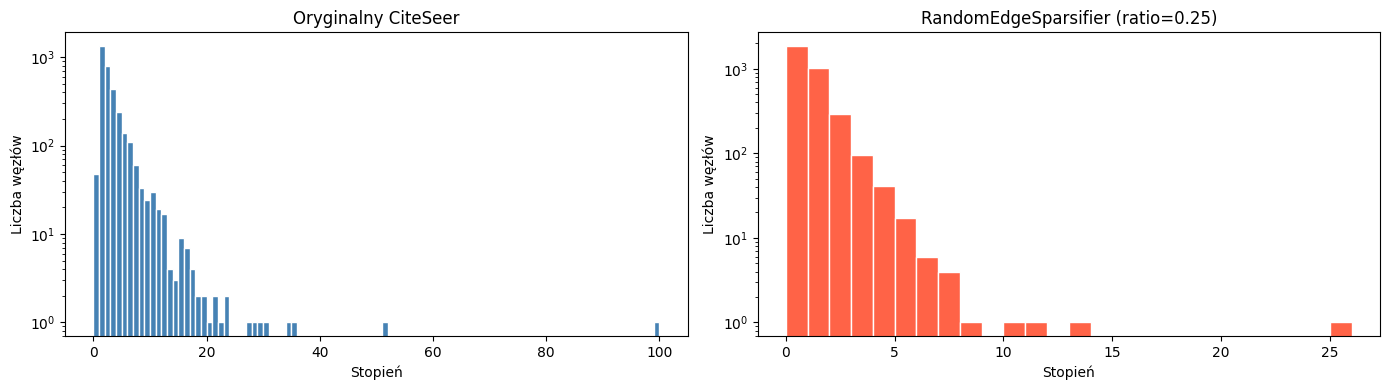

In [10]:
degrees_sparse = [G_sparse_rand.degree(v) for v in G_sparse_rand.iterNodes()]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(degrees, bins=range(max(degrees) + 2), color='steelblue', edgecolor='white')
axes[0].set_title('Oryginalny CiteSeer')
axes[0].set_xlabel('Stopień'); axes[0].set_ylabel('Liczba węzłów')
axes[0].set_yscale('log')

axes[1].hist(degrees_sparse, bins=range(max(degrees_sparse) + 2), color='tomato', edgecolor='white')
axes[1].set_title(f'RandomEdgeSparsifier (ratio={edge_ratio})')
axes[1].set_xlabel('Stopień'); axes[1].set_ylabel('Liczba węzłów')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

c) Wykorzystajwybranyalgorytmsparsyfikacjiznetworkit.sparsification,
przygotuj dla niego wykres oraz analizę z poprzedniej części zadania.

LocalSimilaritySparsifier – krawędzie: 2568
Network Properties:
nodes, edges			3327, 2568
directed?			False
weighted?			False
isolated nodes			48
self-loops			0
density				0.000464
clustering coefficient		0.000000
min/max/avg degree		0, 29, 1.543733
degree assortativity		-0.027109
number of connected components	759
size of largest component	73 (2.19 %)


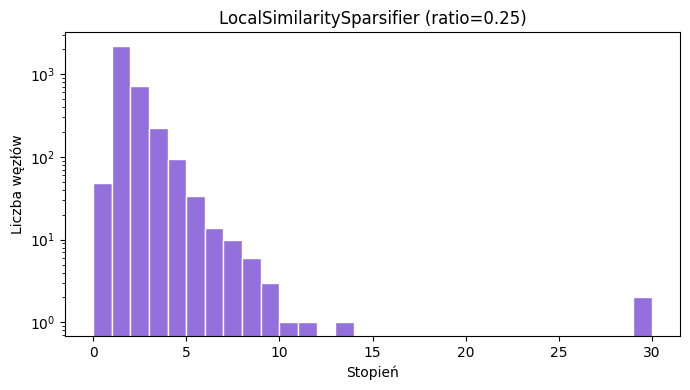

In [11]:
ls_sparsifier = nk.sparsification.LocalSimilaritySparsifier()
G_sparse_ls = ls_sparsifier.getSparsifiedGraphOfSize(G, edge_ratio)

print(f"LocalSimilaritySparsifier – krawędzie: {G_sparse_ls.numberOfEdges()}")

nk.overview(G_sparse_ls)

degrees_ls = [G_sparse_ls.degree(v) for v in G_sparse_ls.iterNodes()]

plt.figure(figsize=(7, 4))
plt.hist(degrees_ls, bins=range(max(degrees_ls) + 2), color='mediumpurple', edgecolor='white')
plt.title(f'LocalSimilaritySparsifier (ratio={edge_ratio})')
plt.xlabel('Stopień'); plt.ylabel('Liczba węzłów')
plt.yscale('log')
plt.tight_layout()
plt.show()

d) PrzetestujinnewartościedgeRatio, jakredukcjakrawędziwpływana
strukturę sieci, jakie wnioski z porównania przeprowadzonych analiz
zauważsz?

In [12]:
ratios = [0.1, 0.25, 0.5, 0.75, 1.0]
results = []

for r in ratios:
    if r == 1.0:
        G_r = G
    else:
        G_r = nk.sparsification.RandomEdgeSparsifier().getSparsifiedGraphOfSize(G, r)
    
    cc = nk.components.ConnectedComponents(G_r)
    cc.run()
    
    deg = [G_r.degree(v) for v in G_r.iterNodes()]
    results.append({
        'ratio': r,
        'edges': G_r.numberOfEdges(),
        'components': cc.numberOfComponents(),
        'avg_degree': np.mean(deg),
    })

df = pd.DataFrame(results)
print(df.to_string(index=False))

 ratio  edges  components  avg_degree
  0.10    431        2900    0.259092
  0.25   1125        2269    0.676285
  0.50   2308        1409    1.387436
  0.75   3367         891    2.024046
  1.00   4552         438    2.736399


##### Wnioski
Przy zmniejszaniu edgeRatio:
- Spada średni stopień węzłów proporcjonalnie do ratio
- Rośnie liczba komponentów spójnych – usuwanie krawędzi fragmentuje sieć
- Przy niskich wartościach (np. 0.1) sieć staje się silnie pofragmentowana 

## Link prediction

celem zadania jest przewidywanie,
czy pomiędzy daną parą węzłów powinna istnieć krawędź.
Problem ten jest formułowany jako zadanie klasyfikacji binarnej,
gdzie:
- klasa pozytywna odpowiada istniejącym krawędziom,
- klasa negatywna odpowiada parom węzłów bez połączenia.

W naszym przypadku celem modelu jest odtworzenie struktury
zredukowanego grafu na podstawie dostępnych danych.

### Negative sampling

proces polegający na losowaniu par węzłów,
które **nie są połączone krawędzią** w grafie.

Jest to kluczowy krok w zadaniu link prediction, ponieważ:
- graf nie zawiera jawnych przykładów negatywnych,
- model klasyfikacyjny wymaga danych obu klas,
- losowanie negatywnych krawędzi umożliwia zbalansowanie zbioru danych.

### Cechy krawędzi (edge features)

w tym ćwiczeniu cechy krawędzi są budowane na podstawie
**embeddingów węzłów uzyskanych metodą Node2Vec**.

Dla każdej krawędzi (u, v):
- pobierane są embeddingi węzłów u i v,
- łączone są w jeden wektor cech.


In [ ]:

def sample_negative_edges(
    G: nk.Graph,
    num_samples: int,
    forbidden_edges: set[tuple[int, int]] | None = None,
) -> np.ndarray:
    """
    Funkcja powinna losować "negatywne krawędzie" w grafie, czyli takie, które nie istnieją w grafie G.

    Parametry
    G : nk.Graph
        Graf wejściowy
    num_samples : int
        Liczba negatywnych krawędzi do wylosowania
    forbidden_edges : set[tuple[int,int]] lub None
        Zbiór krawędzi, których NIE można wylosować (np. istniejących w grafie)

    Wskazówki:
    - Pomiń pętle (u==v)
    - Normalizuj pary dla grafu nieskierowanego (u<=v)
    - Pomijaj krawędzie istniejące i zakazane
    - Wylosowane krawędzie mogą być zwracane w formie np. numpy array
    """
    nodes = list(G.iterNodes())

    forbidden = set()
    if forbidden_edges is not None:
        for u, v in forbidden_edges:
            forbidden.add((min(u, v), max(u, v)))

    for u, v in G.iterEdges():
        forbidden.add((min(u, v), max(u, v)))

    sampled = set()
    while len(sampled) < num_samples:
        u = random.choice(nodes)
        v = random.choice(nodes)
        if u == v:
            continue

        pair = (min(u, v), max(u, v))

        if pair in forbidden or pair in sampled:
            continue

        sampled.add(pair)

    return np.array(list(sampled))


def get_edge_features(
    edge_list: Iterable[tuple[int, int]],
    emb: np.ndarray,
) -> np.ndarray:
    """
    Funkcja ma tworzyć wektory cech dla krawędzi na podstawie embeddingów węzłów.

    Parametry
    edge_list : Iterable[tuple[int,int]]
        Lista krawędzi, np. [(u1,v1), (u2,v2), ...]
    emb : np.ndarray, shape=(n_nodes, embedding_dim)
        Macierz embeddingów węzłów (np. wynik Node2Vec)

    Output
    np.ndarray, shape=(len(edge_list), embedding_dim)
        Każdy wiersz to wektor cech krawędzi, np. iloczyn Hadamarda
        wektorów węzłów u i v

    Wskazówki:
    - Dla każdej krawędzi (u,v) pobierz emb[u] i emb[v]
    - Połącz je w jedną cechę (np. iloczyn Hadamarda)
    - Zbierz wszystkie krawędzie w jedną tablicę numpy
    """
    features = []
    for u, v in edge_list:
        features.append(emb[u] * emb[v])
    return np.array(features)

def preprocess_graph(G: nk.Graph) -> tuple[nk.Graph, dict]:
    """
    Przygotuj graf do Node2Vec

    Wskazówki:
    1. Konwertuj NetworKit -> NetworkX
    2. Usuń izolowane węzły
    3. Przypisz węzłom nowe ID 0..n-1
    4. Konwertuj z powrotem NetworkX -> NetworKit
    """
    G_nx = nk.nxadapter.nk2nx(G)

    isolated = list(nx.isolates(G_nx))
    G_nx.remove_nodes_from(isolated)

    sorted_nodes = sorted(G_nx.nodes())
    mapping = {old: new for new, old in enumerate(sorted_nodes)}
    G_nx = nx.relabel_nodes(G_nx, mapping)

    return nk.nxadapter.nx2nk(G_nx), mapping


a) Wczytaj sieć z pliku 0_9_citeseer.adjlist

In [14]:
data_path = Path('./citeseer/citeseer.adjlist')
reduced_data_path = Path('./citeseer/0_9_citeseer.adjlist')

G_nx = nx.read_adjlist(data_path, nodetype=int)
reduced_G_nx = nx.read_adjlist(reduced_data_path, nodetype=int)


In [15]:
data_path = Path('./citeseer/citeseer.adjlist')
G_nx = nx.read_adjlist(data_path, nodetype=int)
G = nk.nxadapter.nx2nk(G_nx)

reduced_data_path = Path('./citeseer/0_9_citeseer.adjlist')
reduced_G_nx = nx.read_adjlist(reduced_data_path, nodetype=int)
reduced_G = nk.nxadapter.nx2nk(reduced_G_nx)

print(f"Oryginalny graf: {G.numberOfNodes()} węzłów, {G.numberOfEdges()} krawędzi")
print(f"Zredukowany graf: {reduced_G.numberOfNodes()} węzłów, {reduced_G.numberOfEdges()} krawędzi")

Oryginalny graf: 3327 węzłów, 4552 krawędzi
Zredukowany graf: 3327 węzłów, 4094 krawędzi


In [21]:
nx_G_clean = G_nx.copy()
nx_G_clean.remove_nodes_from(list(nx.isolates(nx_G_clean)))
mapping = {old: new for new, old in enumerate(sorted(nx_G_clean.nodes()))}

nx_G_mapped = nx.relabel_nodes(nx_G_clean, mapping)
nx_reduced_mapped = reduced_G_nx.subgraph(
    [n for n in reduced_G_nx.nodes() if n in mapping]
).copy()
nx_reduced_mapped = nx.relabel_nodes(nx_reduced_mapped, mapping)

def nx_to_nk_keep_ids(nx_g: nx.Graph, n: int) -> nk.Graph:
    nk_g = nk.Graph(n, weighted=False, directed=False)
    for u, v in nx_g.edges():
        nk_g.addEdge(u, v)
    return nk_g

n = len(mapping)
preprocessed_G = nx_to_nk_keep_ids(nx_G_mapped, n)
preprocessed_reduced_G = nx_to_nk_keep_ids(nx_reduced_mapped, n)

orig_edges_set    = {(min(u,v), max(u,v)) for u,v in nx_G_mapped.edges()}
reduced_edges_set = {(min(u,v), max(u,v)) for u,v in nx_reduced_mapped.edges()}

removed_edges = list(orig_edges_set - reduced_edges_set)
orig_edges    = list(orig_edges_set)
reduced_edges = list(reduced_edges_set)

print("Oryginalne krawędzie:", len(orig_edges))
print("Zredukowane krawędzie:", len(reduced_edges))
print("Usunięte krawędzie:", len(removed_edges))


Oryginalne krawędzie: 4552
Zredukowane krawędzie: 4094
Usunięte krawędzie: 458


### Node2Vec
model uczenia reprezentacji węzłów w grafach, która odwzorowuje węzły na wektory w przestrzeni ciągłej, zachowując strukturę sieci. Kluczowym elementem node2vec jest *random walk*. Formalnie, dla danego węzła źródłowego $u$ symulujemy random walk o stałej długości $l$. Niech $c_i$ oznacza i‑ty węzeł w ścieżce, zaczynając od $c_0 = u$. Węzły $c_i$ są generowane zgodnie z rozkładem:

$$
P(c_i = x \mid c_{i-1} = v) = 
\begin{cases}
\frac{\pi_{v x}}{Z}, & \text{if} (v,x) \in E, \\
0, & \text{otherwise},
\end{cases}
$$

gdzie \($\pi_{v x}$\) to nienormalizowane prawdopodobieństwo przejścia między węzłami $v$ i $x$, a \($Z$\) jest stałą normalizującą.

Networkit documentation: https://networkit.github.io/dev-docs/python_api/embedding.html


In [22]:
node2vec = Node2Vec(
    G=preprocessed_reduced_G,
    P=1.0,   # return parameter 
    Q=1.0,   # in-out parameter 
    L=80,    # długość random walk
    N=10,    # liczba walk na węzeł
    D=64,    # wymiarowość embeddingu
)
node2vec.run()
emb_matrix = np.array(node2vec.getFeatures())
print("Embeddings shape:", emb_matrix.shape)

Embeddings shape: (3279, 64)


### Budowa zbioru treningowego

W tym zdaniu zbiór treningowy jest budowany poprzez łączenie
próbek pozytywnych i negatywnych.

W kodzie:
- `sample_negative_edges` - wykorzystujemy do losowania par węzłów,
    pomiędzy którymi nie istnieje krawędź w grafie.
- `edge_features`
- `np.vstack` łączy macierze cech:
  - wiersze odpowiadają poszczególnym krawędziom,
  - najpierw krawędzie istniejące, potem negatywne,
- `np.hstack` łączy wektory etykiet:
  - `1` dla krawędzi istniejących,
  - `0` dla krawędzi negatywnych.

Ten sam proces jest wykorzystywny dla sieci powstałej po redukcji służącej jako zbiór treningowej oraz elementom sieci usuniętym w trakcie redukcji służącej jako zbiór testowy.

In [23]:
forbidden = set(orig_edges)
neg_edges = sample_negative_edges(preprocessed_reduced_G, len(reduced_edges), forbidden_edges=forbidden)

X_train = np.vstack([get_edge_features(reduced_edges, emb_matrix),
                     get_edge_features(neg_edges, emb_matrix)])
y_train = np.hstack([np.ones(len(reduced_edges)), np.zeros(len(neg_edges))])

neg_test = sample_negative_edges(preprocessed_reduced_G, len(removed_edges), forbidden_edges=forbidden)
X_test = np.vstack([get_edge_features(removed_edges, emb_matrix),
                    get_edge_features(neg_test, emb_matrix)])
y_test = np.hstack([np.ones(len(removed_edges)), np.zeros(len(neg_test))])

g) Wyucz wybrany algorytm klasyfikacji (KNN, regresja logistyczna lub
inny) oraz przetestuj jego skuteczność.

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# LR
clf_lr = LogisticRegression(max_iter=1000, random_state=SEED)
clf_lr.fit(X_train_scaled, y_train)
y_pred_lr = clf_lr.predict(X_test_scaled)

# KNN
clf_knn = KNeighborsClassifier(n_neighbors=5)
clf_knn.fit(X_train_scaled, y_train)
y_pred_knn = clf_knn.predict(X_test_scaled)

/Users/malwina.juchiewicz/Desktop/SI/sieci-zlozone/laby/sieci-zlozone-env/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/malwina.juchiewicz/Desktop/SI/sieci-zlozone/laby/sieci-zlozone-env/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/malwina.juchiewicz/Desktop/SI/sieci-zlozone/laby/sieci-zlozone-env/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/malwina.juchiewicz/Desktop/SI/sieci-zlozone/laby/sieci-zlozone-env/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/malwina.

In [25]:
print("Test F1 LR:", f1_score(y_test, y_pred_lr, average="macro"))
print("Test F1 KNN:", f1_score(y_test, y_pred_knn, average="macro"))

Test F1 LR: 0.746528851631806
Test F1 KNN: 0.7470331035292853
